In [ ]:
!pip install keras-tuner --upgrade 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.6 MB/s eta 0:00:00


In [2]:
!pip install yfinance

In [3]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Input, Dense, Dropout, Concatenate
import os
import json
import warnings
import yfinance as yf
import keras_tuner as kt
warnings.filterwarnings('ignore')

# Download & Load Dataset

In [4]:
ticker = 'GOOG'
df = yf.download(ticker, start='2020-01-01', end='2025-01-01')
print(df.info())
print(df.head())

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   1258 non-null   float64
 1   (High, GOOG)    1258 non-null   float64
 2   (Low, GOOG)     1258 non-null   float64
 3   (Open, GOOG)    1258 non-null   float64
 4   (Volume, GOOG)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
None
Price           Close       High        Low       Open    Volume
Ticker           GOOG       GOOG       GOOG       GOOG      GOOG
Date                                                            
2020-01-02  67.811760  67.849944  66.531272  66.531272  28132000
2020-01-03  67.478996  68.066178  66.729352  66.844208  23728000
2020-01-06  69.142838  69.256400  66.950335  66.950335  34646000
2020-01-07  69.099701  69.578270  68.952903  69.327831  30054000
2020-01-08  69.644226  70.004269  68.975711  69.03

In [5]:
close_data = df.Close

N = len(close_data)
print(f'Jumlah data: {N}')

print()
print(close_data)

Jumlah data: 1258

Ticker            GOOG
Date                  
2020-01-02   67.811760
2020-01-03   67.478996
2020-01-06   69.142838
2020-01-07   69.099701
2020-01-08   69.644226
...                ...
2024-12-24  196.665283
2024-12-26  196.197418
2024-12-27  193.151443
2024-12-30  191.807632
2024-12-31  189.567932

[1258 rows x 1 columns]


Text(0.5, 1.0, 'Stock Closing Price')

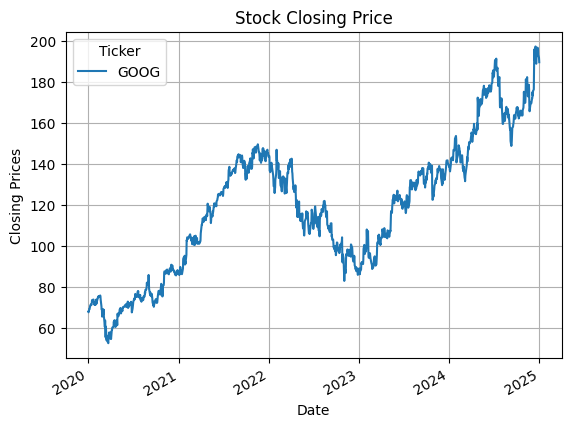

In [25]:
df.Close.plot()
plt.grid()

plt.xlabel('Date')
plt.ylabel('Closing Prices')
plt.title('Stock Closing Price')

In [7]:
X_steps = 30
y_steps = 5

In [8]:
split_index = int(N * 0.8)

train = close_data[:split_index].astype(np.float32).values.reshape(-1, 1)
test = close_data[split_index - X_steps:].astype(np.float32).values.reshape(-1, 1)

In [9]:
# Scalling
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [10]:
# windowing dataset
def make_windows(series, x_steps, y_steps):
  X, y = [], []
  T = len(series)

  for t in range(x_steps, T - y_steps + 1):
        X.append(series[t - x_steps:t])
        y.append(series[t:t + y_steps])
  return np.array(X), np.array(y)

In [11]:
# Scaled Train & Test
X_train, y_train = make_windows(train_scaled, X_steps, y_steps)
X_test, y_test = make_windows(test_scaled, X_steps, y_steps)

In [12]:
y_train = y_train.reshape(y_train.shape[0], y_train.shape[1])
y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (972, 30, 1)
y_train: (972, 5)
X_test : (248, 30, 1)
y_test : (248, 5)


In [13]:
def build_LSTM_model(hp):
    model = Sequential()
    n_hidden_layers = hp.Int('n_hidden_layers', 1, 5, step=1)

    first_layer_return = True if n_hidden_layers > 1 else False

    model.add(LSTM(
        units=hp.Choice('units_0', [16, 32, 64, 128]),
        input_shape=(X_train.shape[1], X_train.shape[2]),
        return_sequences=first_layer_return
    ))
    model.add(Dropout(hp.Float('dropout_0', 0.0, 0.4, step=0.1)))

    # Hidden Layers Berikutnya
    for i in range(1, n_hidden_layers):
        is_last_lstm = (i == n_hidden_layers - 1)

        model.add(LSTM(
            units=hp.Choice(f'units_{i}', [16, 32, 64, 128]),
            return_sequences=not is_last_lstm
        ))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1)))

    model.add(Dense(y_steps))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        ),
        loss="mae",
        metrics=['mae']
    )

    return model

In [14]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=7, restore_best_weights=True)

In [15]:
tuner = kt.Hyperband(build_LSTM_model,
                     objective='val_mae',
                     max_epochs=50,
                     factor=3,
                     directory='kt_dir',
                     project_name='google_lstm',
                     overwrite=True)

tuner.search(X_train, y_train, epochs=50, validation_split= 0.1,
             callbacks=[stop_early], shuffle=False)

Trial 90 Complete [00h 01m 22s]
val_mae: 0.08097950369119644

Best val_mae So Far: 0.03745338320732117
Total elapsed time: 00h 31m 24s


In [16]:
# get best hp
best_hp = tuner.get_best_hyperparameters(num_trials=3)[0]
print("Best Hyperparameters:")
print(best_hp.values)

Best Hyperparameters:
{'n_hidden_layers': 1, 'units_0': 128, 'dropout_0': 0.4, 'learning_rate': 0.0012122097619092932, 'units_1': 16, 'dropout_1': 0.0, 'units_2': 32, 'dropout_2': 0.1, 'units_3': 16, 'dropout_3': 0.30000000000000004, 'units_4': 16, 'dropout_4': 0.0, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 3, 'tuner/round': 0}


In [17]:
lstm_model = tuner.hypermodel.build(best_hp)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,205 (262.52 KB)

 Trainable params: 67,205 (262.52 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
lstm_model.fit(X_train, y_train, epochs=100, validation_split=0.1, callbacks=[stop_early])

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0612 - mae: 0.0612 - val_loss: 0.0535 - val_mae: 0.0535
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0598 - mae: 0.0598 - val_loss: 0.0602 - val_mae: 0.0602
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0594 - mae: 0.0594 - val_loss: 0.0688 - val_mae: 0.0688
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0588 - mae: 0.0588 - val_loss: 0.0444 - val_mae: 0.0444
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0548 - mae: 0.0548 - val_loss: 0.0397 - val_mae: 0.0397
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0548 - mae: 0.0548 - val_loss: 0.0459 - val_mae: 0.0459
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0512 - mae: 0.0512 - val_loss: 0.0393 - val_mae: 0.0393
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0502 - mae: 0.0502 - val_loss: 0.0476 - val_mae: 0.0476
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - lo

In [21]:
predictions = lstm_model.predict(X_test)
lstm_preds = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_unscaled, lstm_preds)

print(f"Unscaled Mean Absolute Error (MAE) for LSTM model: {round(mae, 3)}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Unscaled Mean Absolute Error (MAE) for LSTM model: 4.234


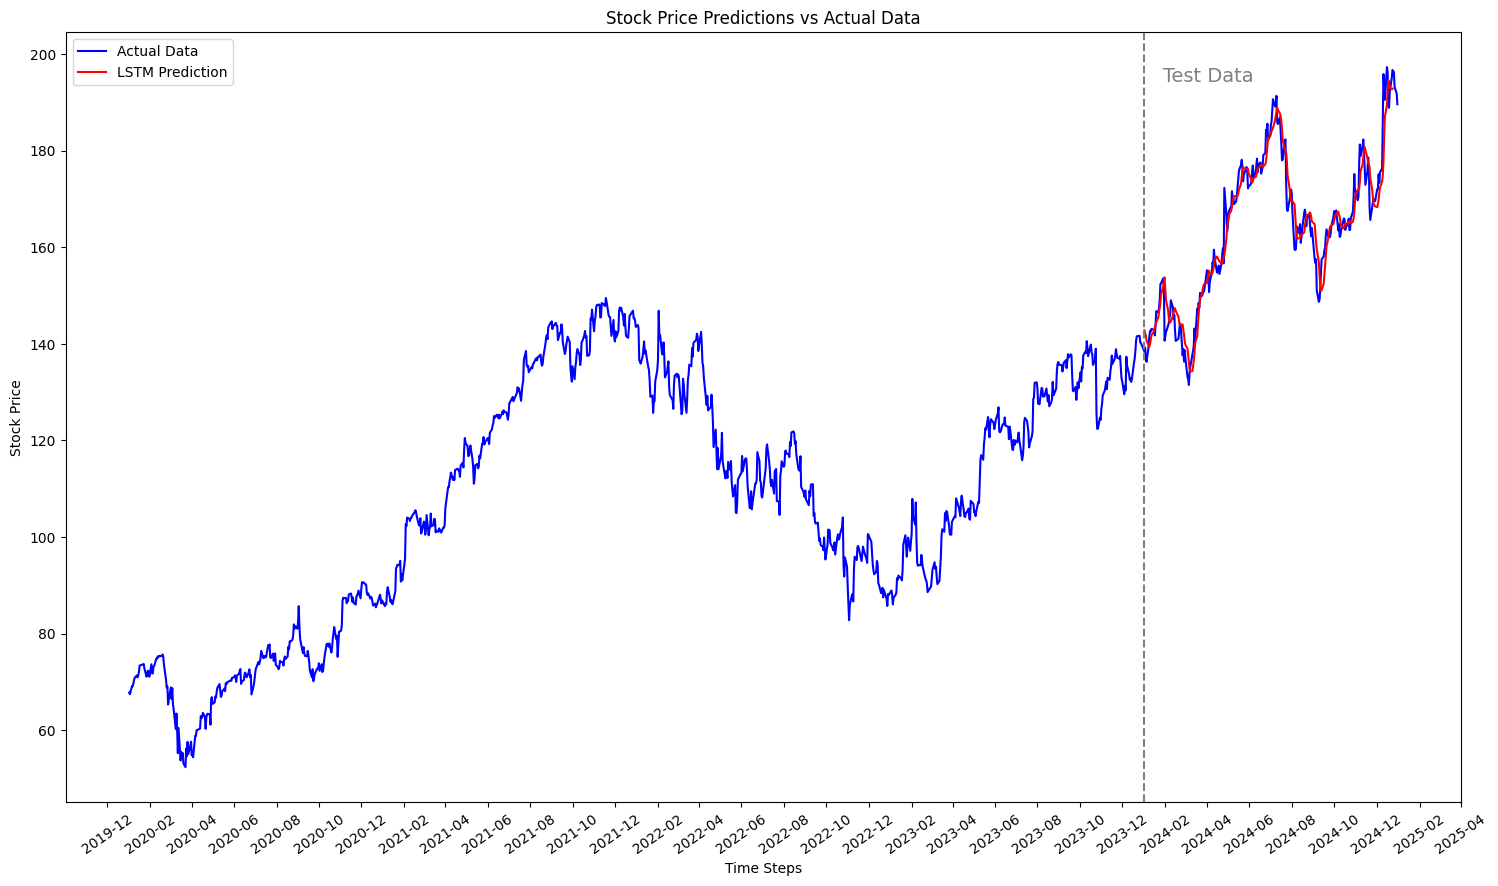

In [27]:
train_dates = close_data[:split_index].index[:len(y_train)]
test_dates = close_data[split_index:].index[:len(y_test)]

# Flatten and inverse scale
y_train_actual = close_data[:split_index][:len(y_train)]
y_test_actual= scaler.inverse_transform(y_test)

plt.figure(figsize=(18,10))

# Plot training data
plt.plot(close_data.index, close_data, label='Actual Data', color='blue')

# Plot predictions on test data
plt.plot(test_dates, lstm_preds[:, 0], label='LSTM Prediction', color='red')

# Add vertical dashed line to separate train/test
split_date = close_data.index[split_index]
plt.axvline(x=split_date, color='gray', linestyle='--')
# Add text for Test Data
plt.text(split_date, plt.ylim()[1]*0.95, '   Test Data', color='gray', fontsize=14)

# Set x-axis ticks for time steps
plt.xticks(rotation=35)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.title('Stock Price Predictions vs Actual Data')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

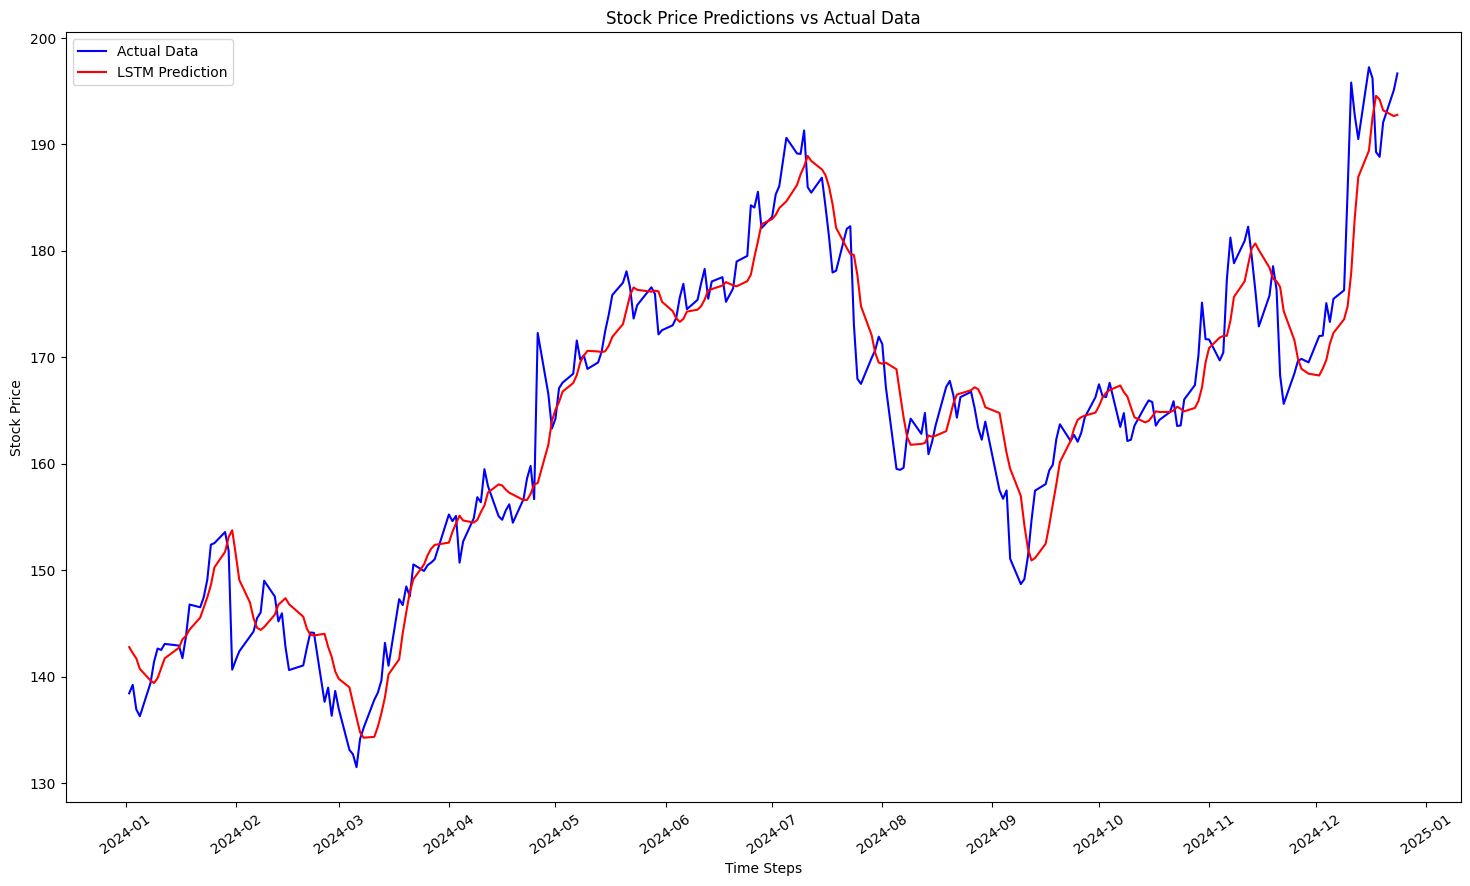

In [28]:
test_dates = close_data.index[split_index : split_index + len(y_test)]

plt.figure(figsize=(18,10))

# Plot actual test data (aligned to prediction samples)
plt.plot(test_dates, close_data[split_index : split_index + len(y_test)].values,
         label='Actual Data', color='blue')

# Plot predictions
plt.plot(test_dates, lstm_preds[:, 0], label='LSTM Prediction', color='red')

# Set x-axis ticks for time steps
plt.xticks(rotation=35)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.title('Stock Price Predictions vs Actual Data')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [23]:
lstm_model.save('model_stock_price.keras')

In [26]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']